EDA

In [390]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [391]:
df = pd.read_csv('insurance2.csv')

In [392]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,51,female,41.90,106,No,0,No,southeast,24227.34
1,2,37,female,33.40,84,Yes,0,No,northwest,12231.61
2,3,36,female,30.20,130,No,1,Yes,northwest,43943.88
3,4,39,female,27.60,104,Yes,1,Yes,southwest,24520.26
4,5,38,female,25.30,104,Yes,1,Yes,northeast,21771.34


In [393]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             9000 non-null   int64  
 1   age            9000 non-null   int64  
 2   gender         9000 non-null   object 
 3   bmi            9000 non-null   float64
 4   bloodpressure  9000 non-null   int64  
 5   diabetic       9000 non-null   object 
 6   children       9000 non-null   int64  
 7   smoker         9000 non-null   object 
 8   region         9000 non-null   object 
 9   claim          9000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 703.3+ KB


In [394]:
df.shape

(9000, 10)

In [395]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [396]:
sns.set(style="whitegrid", palette="muted", font_scale=1.2, color_codes=True)

In [397]:
df.duplicated().sum()

np.int64(0)

In [398]:
df.isna().sum()

Id               0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

In [399]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [400]:
df.describe(include='all')

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,9000.00,9000.00,9000,9000.00,9000.00,9000,9000.00,9000,9000,9000.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,4554,NaN,NaN,4734,NaN,7145,2923,NaN
mean,4500.50,38.10,NaN,30.59,94.28,NaN,1.08,NaN,NaN,13426.27
std,2598.22,11.17,NaN,6.09,11.57,NaN,1.19,NaN,NaN,12102.55
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,2250.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4846.92
50%,4500.50,38.00,NaN,30.20,92.00,NaN,1.00,NaN,NaN,9583.89
75%,6750.25,47.00,NaN,34.70,99.00,NaN,2.00,NaN,NaN,17085.27


In [401]:
numerical_cols = ["age", "bmi", "children", "claim", "bloodpressure"]
categorical_cols = df.select_dtypes(include=['object']).columns

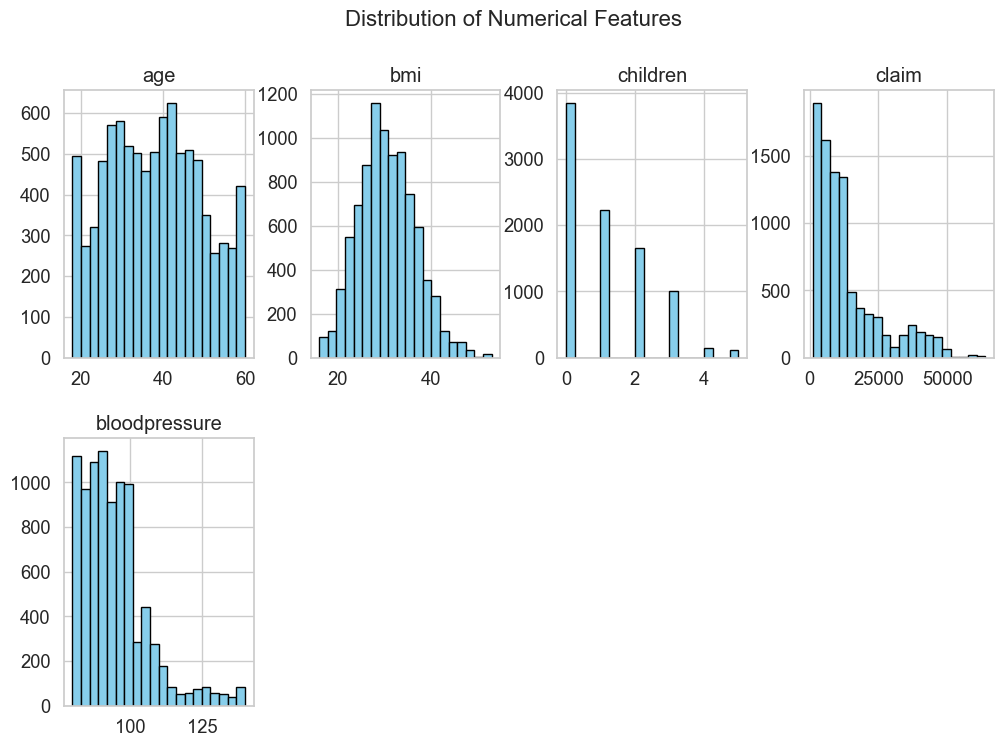

In [402]:
df[numerical_cols].hist(bins=20, figsize=(12,8), color='skyblue', edgecolor='black', layout=(2, 4))
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.show()

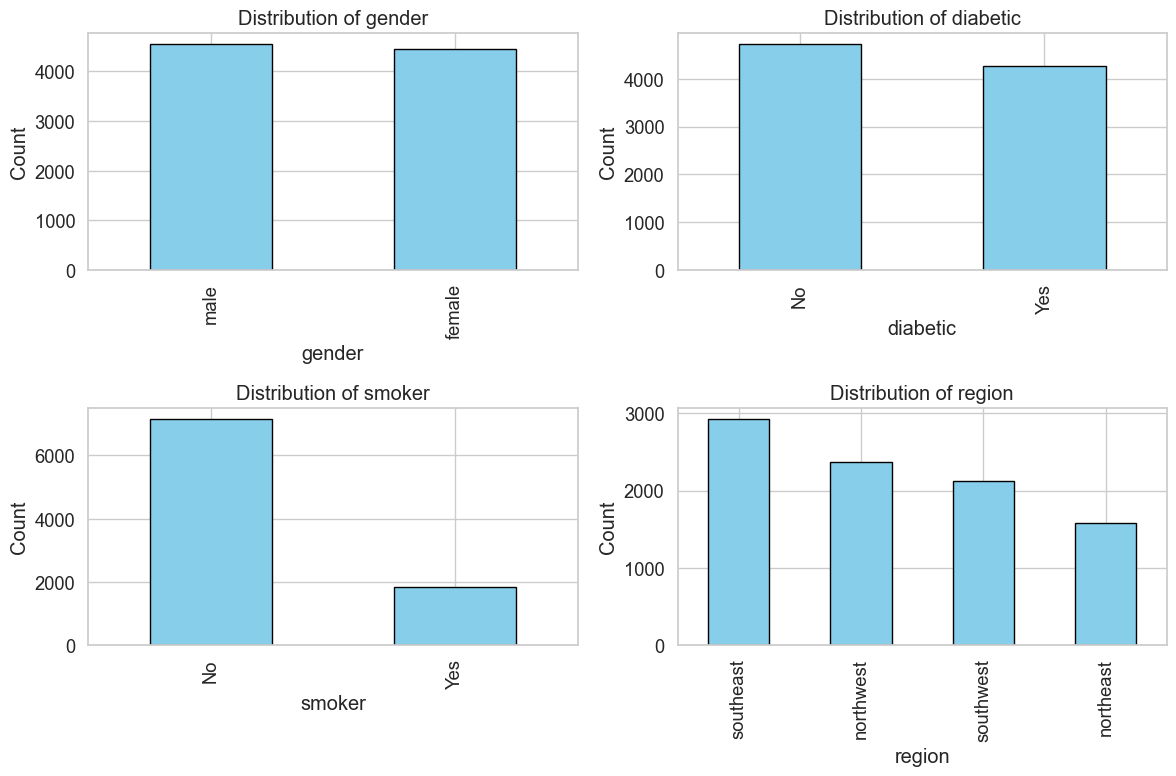

In [403]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
	df[col].value_counts().plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
	axes[idx].set_title(f'Distribution of {col}')
	axes[idx].set_xlabel(col)
	axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [404]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2)

gender  smoker
female  No        9020.98
        Yes      30997.87
male    No        8164.39
        Yes      32656.06
Name: claim, dtype: float64

Text(0, 0.5, 'Average Claim Amount')

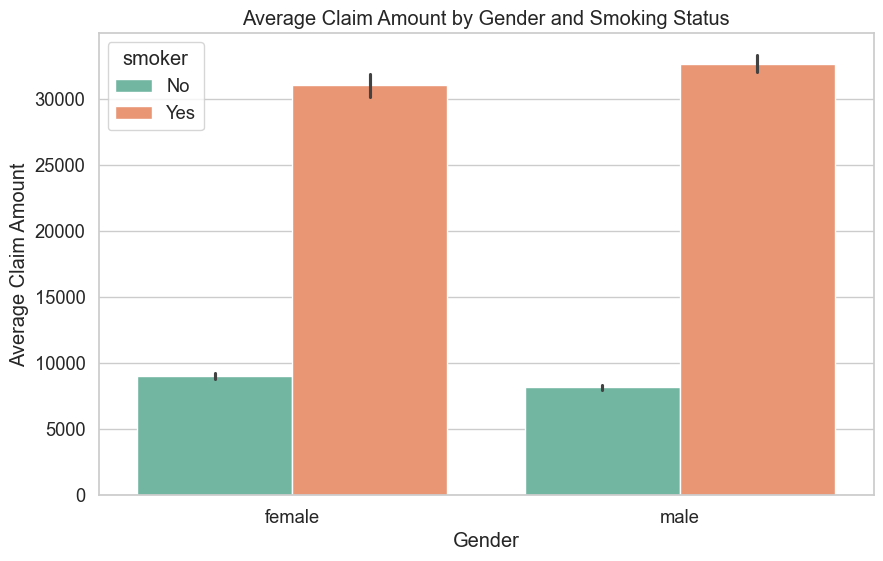

In [405]:
plt.figure(figsize=(10, 6))
sns.barplot(data = df, x ="gender", y="claim", hue="smoker",estimator="mean", palette="Set2")
plt.title('Average Claim Amount by Gender and Smoking Status')
plt.xlabel('Gender')
plt.ylabel('Average Claim Amount')  

In [406]:
pivot_region_diabetic = df.groupby(["region", "diabetic"])["claim"].mean().unstack()

In [407]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,17157.67,17060.61
northwest,11736.62,12318.59
southeast,13331.01,12335.37
southwest,13281.85,12822.75


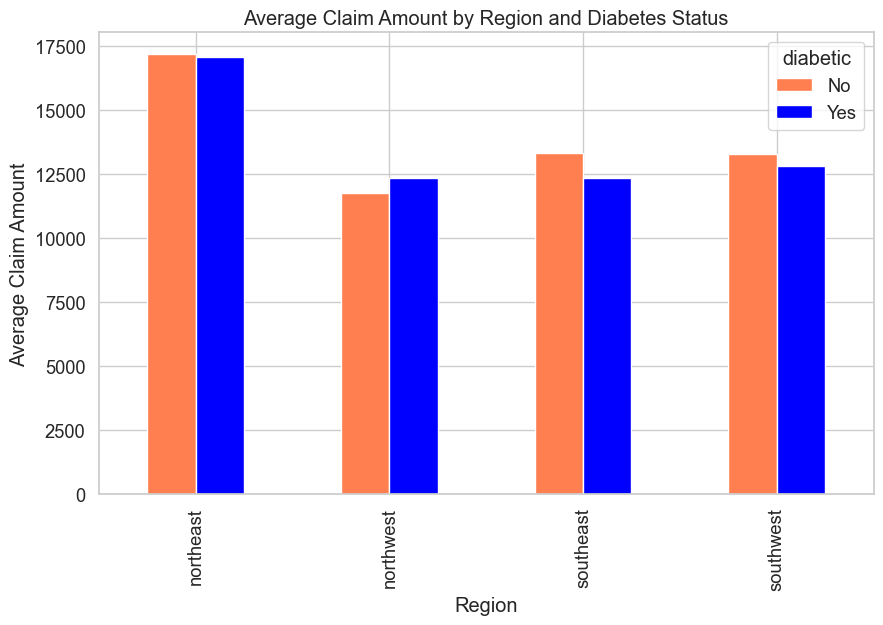

In [408]:
pivot_region_diabetic.plot(kind='bar', figsize=(10, 6), color=['coral', 'blue'])
plt.title('Average Claim Amount by Region and Diabetes Status')
plt.ylabel('Average Claim Amount')
plt.xlabel('Region')    
plt.show()

In [409]:
pivot_table = pd.pivot_table(df, values="claim", index=["region"], columns=["smoker"], aggfunc="mean")

In [410]:
pivot_table

smoker,No,Yes
region,,
northeast,12074.71,29477.25
northwest,8170.93,30491.76
southeast,7406.02,34864.37
southwest,8472.17,32194.01


In [411]:
pivot_table = df.pivot_table(values='claim', index='children', columns='diabetic', aggfunc='mean')
pivot_table

diabetic,No,Yes
children,,
0,12928.51,11782.47
1,12842.58,12737.70
2,15609.27,15051.29
3,14380.53,18221.34
4,13972.19,13449.86
5,8760.20,9853.80


In [412]:
numerical_cols

['age', 'bmi', 'children', 'claim', 'bloodpressure']

In [413]:
df[numerical_cols].corr()

,age,bmi,children,claim,bloodpressure
age,1.00,-0.06,-0.05,-0.02,-0.04
bmi,-0.06,1.00,0.03,0.20,0.16
children,-0.05,0.03,1.00,0.08,-0.04
claim,-0.02,0.20,0.08,1.00,0.53
bloodpressure,-0.04,0.16,-0.04,0.53,1.00


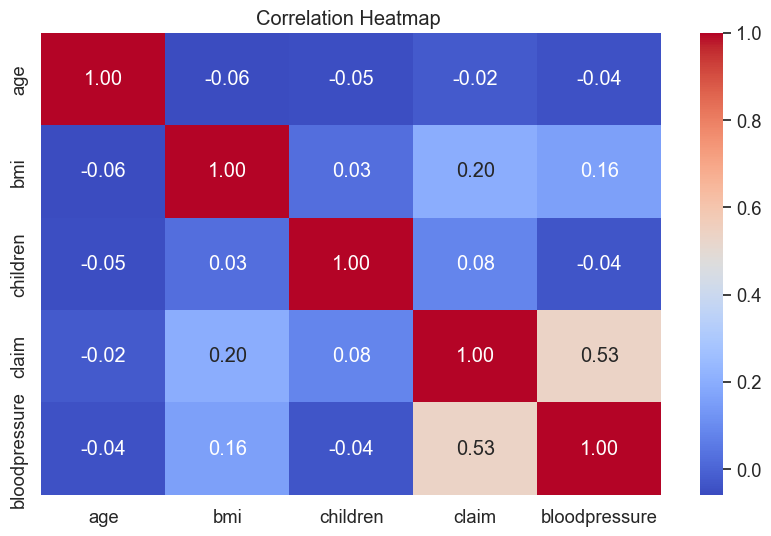

In [414]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm',  fmt=".2f")
plt.title('Correlation Heatmap ')
plt.show()

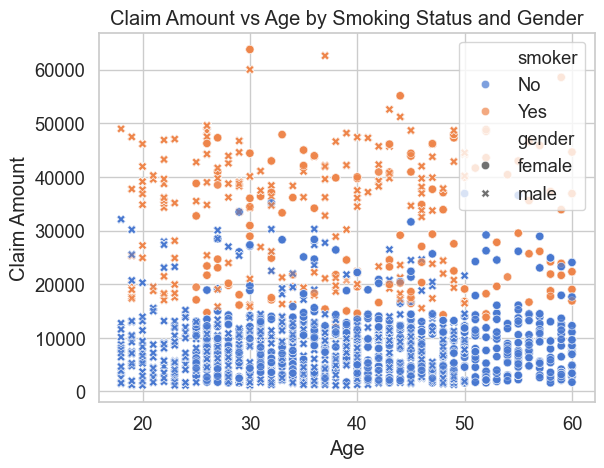

In [415]:
sns.scatterplot(data=df, x='age', y='claim', hue='smoker', style="gender", alpha=0.7)
plt.title('Claim Amount vs Age by Smoking Status and Gender')
plt.xlabel('Age')
plt.ylabel('Claim Amount')
plt.show()

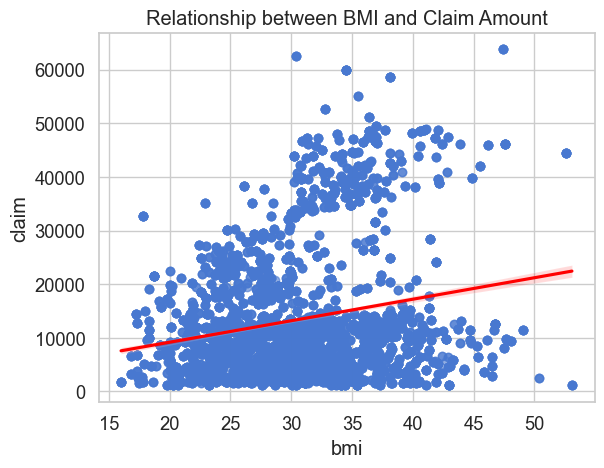

In [416]:
sns.regplot(data=df, x='bmi', y='claim', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Relationship between BMI and Claim Amount')
plt.show()

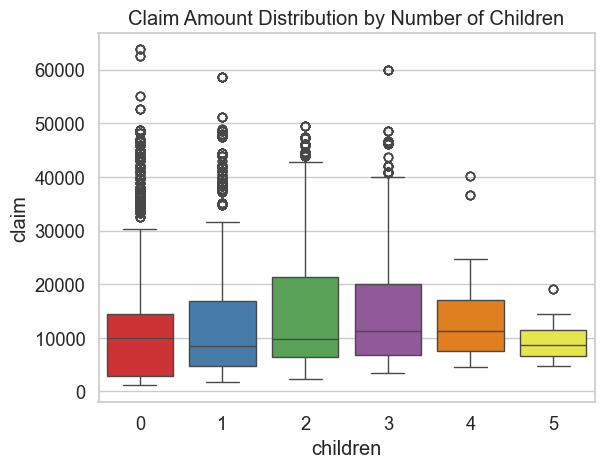

In [417]:
sns.boxplot(data=df, x='children', y='claim', palette='Set1')
plt.title('Claim Amount Distribution by Number of Children')
plt.show()

In [418]:
df["age_group"] = pd.cut(df["age"], bins=[0, 18, 30, 45, 60, 100], labels=["<18", "18-30", "31-45", "45-60", "60+"])


In [419]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,51,female,41.90,106,No,0,No,southeast,24227.34,45-60
1,2,37,female,33.40,84,Yes,0,No,northwest,12231.61,31-45
2,3,36,female,30.20,130,No,1,Yes,northwest,43943.88,31-45
3,4,39,female,27.60,104,Yes,1,Yes,southwest,24520.26,31-45
4,5,38,female,25.30,104,Yes,1,Yes,northeast,21771.34,31-45
...,...,...,...,...,...,...,...,...,...,...,...
8995,8996,37,male,24.80,85,No,3,No,northeast,9500.57,31-45
8996,8997,57,female,34.80,96,No,1,No,southwest,5246.05,45-60
8997,8998,19,male,24.70,97,Yes,1,No,northwest,30166.62,18-30
8998,8999,58,female,29.60,95,Yes,0,No,southwest,5910.94,45-60


In [420]:
df["age_group"].value_counts()

age_group
31-45    3703
18-30    2623
45-60    2574
<18       100
60+         0
Name: count, dtype: int64

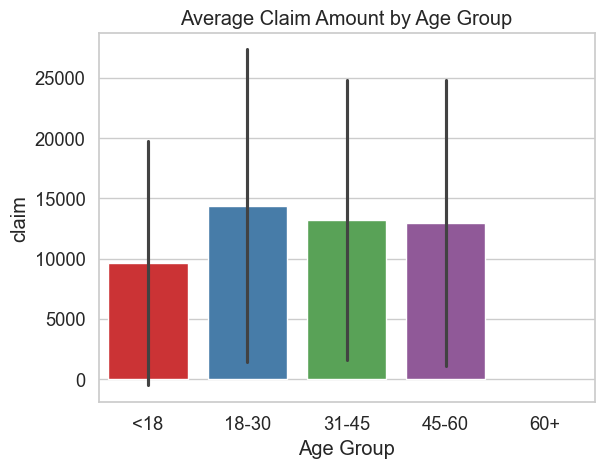

In [421]:
sns.barplot(data=df, x='age_group', y='claim', palette='Set1', estimator=np.mean, errorbar="sd")
plt.title('Average Claim Amount by Age Group')
plt.xlabel('Age Group') 
plt.show()

In [422]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 24.9, 29.9, 100], labels=["Underweight", "Normal weight", "Overweight", "Obesity"])


In [423]:
df["bmi_category"].value_counts()

bmi_category
Obesity          4669
Overweight       2693
Normal weight    1492
Underweight       146
Name: count, dtype: int64

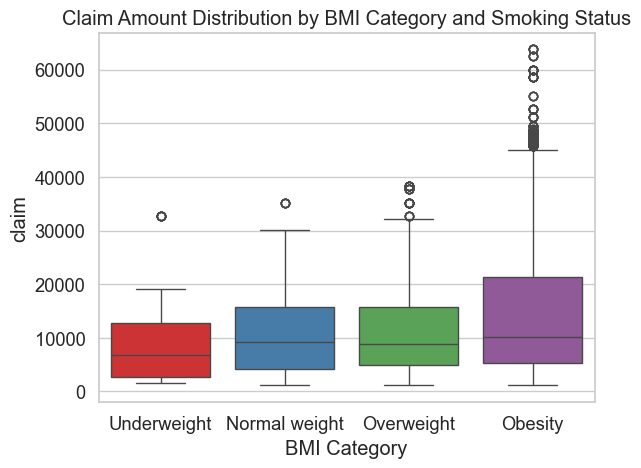

In [424]:
sns.boxplot(data=df, x='bmi_category', y='claim', palette='Set1')
plt.title('Claim Amount Distribution by BMI Category and Smoking Status')
plt.xlabel('BMI Category')  
plt.show()

In [425]:
region_stats = df.groupby('region').agg(
    smoker_rate=('smoker', lambda x: (x == 'Yes').mean() * 100),    
    mean_claim=('claim', 'mean')
).reset_index()


In [426]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,28.91,17106.51
1,northwest,17.12,11991.70
2,southeast,19.84,12854.48
3,southwest,19.37,13067.09


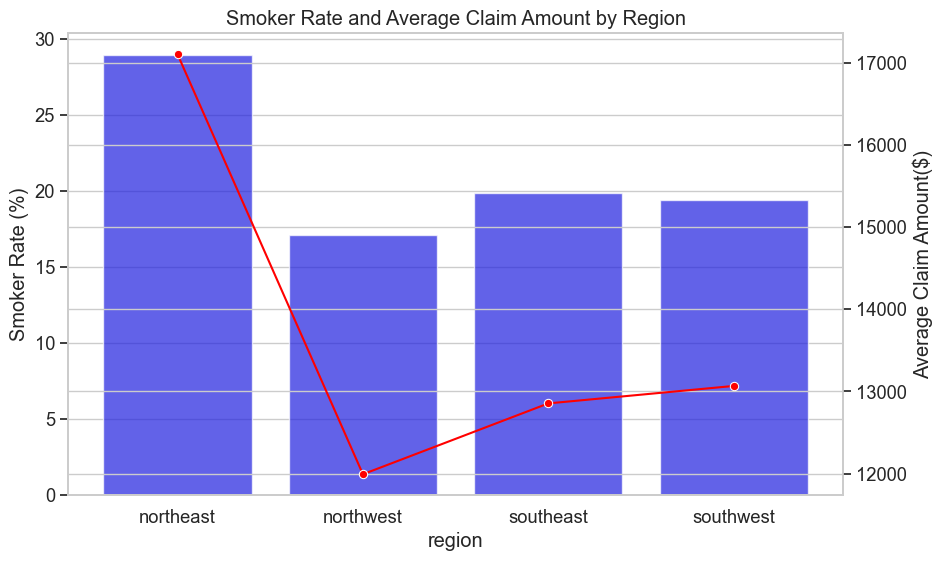

In [427]:
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.barplot(data=region_stats, x='region', y='smoker_rate', ax=ax1,alpha = 0.7, color='blue')
ax2 = ax1.twinx()
sns.lineplot(data=region_stats, x='region', y='mean_claim', ax=ax2, color='red', marker='o')
ax1.set_ylabel('Smoker Rate (%)')
ax2.set_ylabel('Average Claim Amount($)' )
plt.title('Smoker Rate and Average Claim Amount by Region')
plt.show()

Data Preprocessing & Feature Engeneering

In [428]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import joblib

In [429]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [430]:
x = df[["age", "gender", "bmi","bloodpressure","diabetic","children","smoker"]]
y = df["claim"]

In [431]:
x

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,51,female,41.90,106,No,0,No
1,37,female,33.40,84,Yes,0,No
2,36,female,30.20,130,No,1,Yes
3,39,female,27.60,104,Yes,1,Yes
4,38,female,25.30,104,Yes,1,Yes
...,...,...,...,...,...,...,...
8995,37,male,24.80,85,No,3,No
8996,57,female,34.80,96,No,1,No
8997,19,male,24.70,97,Yes,1,No
8998,58,female,29.60,95,Yes,0,No


In [432]:
cat_cols = ["gender", "diabetic", "smoker"]
label_encoders = {}

In [433]:
for col in cat_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le

    joblib.dump(le, f"label_encoder_{col}.pkl")

In [434]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [435]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [436]:
num_cols = ["age", "bmi", "bloodpressure", "children"]
scaler = StandardScaler()

In [437]:
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

In [438]:
joblib.dump(scaler, "standard_scaler.pkl")

['standard_scaler.pkl']

In [439]:
print(x_train.shape, y_train.shape)

(7200, 7) (7200,)


In [440]:
print(x_test.shape, y_test.shape)

(1800, 7) (1800,)


Training Machine Learning Models

In [441]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [442]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
    # Predict on the test set and compute metrics
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2": r2, "MAE": mae, "RMSE": rmse}

In [443]:
results = {}

In [444]:
lr = LinearRegression()
lr.fit(x_train, y_train)
results["Linear Regression"] = evaluate_model(lr, x_train, x_test, y_train, y_test)
print("Linear Regression Model Trained ")


best_poly_model = None
best_poly_score = -np.inf

for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    poly_lr = LinearRegression()
    poly_lr.fit(x_train_poly, y_train)

    score = poly_lr.score(x_test_poly, y_test)
    if score > best_poly_score:

        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model

results[f"Polynomial Regression (degree={degree})"] = evaluate_model(poly_lr, poly.fit_transform(x_train), poly.transform(x_test), y_train, y_test)
print(f"Polynomial Regression Model Trained") 

rf = RandomForestRegressor()
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, n_jobs= -1, scoring='r2', verbose=0)
rf_grid.fit(x_train, y_train)
best_rf = rf_grid.best_estimator_

results['Random Forest'] = evaluate_model(best_rf, x_train, x_test, y_train, y_test)

print("Random Forest Model Trained, best parameters:", rf_grid.best_params_)

svr = SVR()
svr_params = {
    'C': [1, 10, 50],
    'kernel': ['linear', 'rbf', "poly"],
    'degree': [2, 3],
    'epsilon': [0.1, 0.2, 0.5]

}

svr_grid = GridSearchCV(svr, svr_params, cv=3, n_jobs=-1, scoring='r2', verbose=0)
svr_grid.fit(x_train, y_train)

best_svr = svr_grid.best_estimator_

results['SVR'] = evaluate_model(best_svr, x_train, x_test, y_train, y_test)

print("Support Vector Regression Model Trained, best parameters:", svr_grid.best_params_)

xgb = XGBRegressor(objective='reg:squarederror')

xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [ 0.8, 1.0]
}
colsample_bytree = [0.8, 1.0]
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, n_jobs=-1, scoring='r2', verbose=0)
xgb_grid.fit(x_train, y_train)
best_xgb = xgb_grid.best_estimator_

results['XGBoost'] = evaluate_model(best_xgb, x_train, x_test, y_train, y_test)

print("XGBoost Model Trained, best parameters:", xgb_grid.best_params_)

Linear Regression Model Trained 
Polynomial Regression Model Trained
Random Forest Model Trained, best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Support Vector Regression Model Trained, best parameters: {'C': 50, 'degree': 2, 'epsilon': 0.1, 'kernel': 'linear'}
XGBoost Model Trained, best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


In [445]:
results

{'Linear Regression': {'R2': 0.699311947035179,
  'MAE': 5194.818690660693,
  'RMSE': np.float64(6839.046161665789)},
 'Polynomial Regression (degree=3)': {'R2': 0.7992123450215972,
  'MAE': 4127.824828745795,
  'RMSE': np.float64(5588.637652912727)},
 'Random Forest': {'R2': 0.9983886187031646,
  'MAE': 134.46176280557128,
  'RMSE': np.float64(500.65275218926956)},
 'SVR': {'R2': 0.6599255175532337,
  'MAE': 5142.1857940522295,
  'RMSE': np.float64(7273.1822729634005)},
 'XGBoost': {'R2': 0.9948837710421619,
  'MAE': 559.3443334147134,
  'RMSE': np.float64(892.0977302304749)}}

In [446]:
results_df = pd.DataFrame(results).T.sort_values(by='R2', ascending=False)
results_df

,R2,MAE,RMSE
Random Forest,1.00,134.46,500.65
XGBoost,0.99,559.34,892.10
Polynomial Regression (degree=3),0.80,4127.82,5588.64
Linear Regression,0.70,5194.82,6839.05
SVR,0.66,5142.19,7273.18


In [447]:
models = {
    "Linear Regression": lr,
    "Polynomial Regression": poly_lr,
    "Random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [448]:
best_r2 = results_df["R2"].max()

In [449]:
best_r2

np.float64(0.9983886187031646)

In [450]:
top_model_name = results_df[results_df["R2"] == best_r2]

In [451]:
top_model_name

,R2,MAE,RMSE
Random Forest,1.00,134.46,500.65


In [452]:
best_model = models[top_model_name.index[0]]

In [453]:
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [454]:
joblib.dump(best_model, "best_model.pkl")
print(f"Best model selected : {top_model_name.index[0]}")

Best model selected : Random Forest
